# Mini Project: Klasifikasi Emosi Tweet Bahasa Indonesia
## Menggunakan RNN dan Variannya (LSTM, GRU, Bidirectional LSTM)

**Dataset:** Indonesian Twitter Emotion Dataset  
**Kelas Emosi:** anger, happy, sadness, fear, love  


In [ ]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU,
    Bidirectional, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

import re
import string

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2


# Part A - Step 1: Load & Eksplorasi Dataset


In [ ]:
df = pd.read_csv('Twitter_Emotion_Dataset.csv')

print("=" * 50)
print("INFO DATASET")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
print("\nContoh Data:")
display(df.head(8))

print("\nDistribusi Label:")
print(df['label'].value_counts())

INFO DATASET
Shape: (4401, 2)
Kolom: ['label', 'tweet']

Contoh Data:


,label,tweet
0,anger,"Soal jln Jatibaru,polisi tdk bs GERTAK gubernu..."
1,anger,"Sesama cewe lho (kayaknya), harusnya bisa lebi..."
2,happy,Kepingin gudeg mbarek Bu hj. Amad Foto dari go...
3,anger,"Jln Jatibaru,bagian dari wilayah Tn Abang.Peng..."
4,happy,"Sharing pengalaman aja, kemarin jam 18.00 bata..."
5,anger,"Dari sekian banyak thread yang aku baca, threa..."
6,happy,Sharing sama temen tuh emg guna bgt. Disaat lu...
7,sadness,Orang lain kalau pake ponco itu buat jas hujan...



Distribusi Label:
label
anger      1101
happy      1017
sadness     997
fear        649
love        637
Name: count, dtype: int64


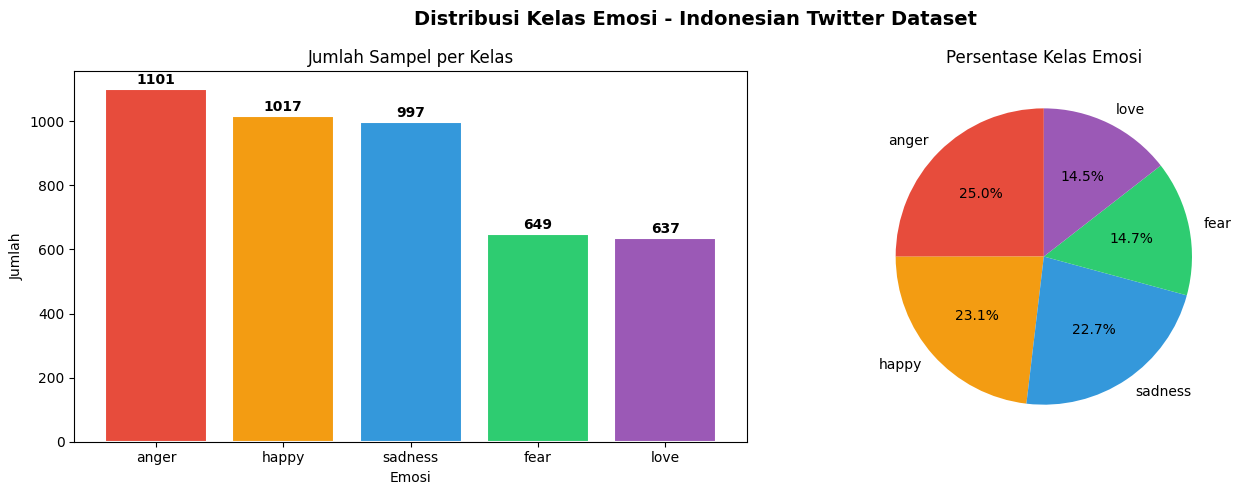

Grafik disimpan: distribusi_kelas.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Kelas Emosi - Indonesian Twitter Dataset', fontsize=14, fontweight='bold')

label_counts = df['label'].value_counts()
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']

axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Jumlah Sampel per Kelas', fontsize=12)
axes[0].set_xlabel('Emosi')
axes[0].set_ylabel('Jumlah')
for i, (idx, val) in enumerate(label_counts.items()):
    axes[0].text(i, val + 15, str(val), ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Persentase Kelas Emosi', fontsize=12)

plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: distribusi_kelas.png")

# Part A - Step 2: Preprocessing Teks

In [ ]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['tweet_clean'] = df['tweet'].apply(preprocess_text)
df = df[df['tweet_clean'].str.len() > 0].reset_index(drop=True)

print("Contoh hasil preprocessing:")
for i in range(3):
    print(f"\n[{i+1}] ORIGINAL : {df['tweet'][i][:80]}")
    print(f"    CLEANED  : {df['tweet_clean'][i][:80]}")

df['tweet_len'] = df['tweet_clean'].apply(lambda x: len(x.split()))
print(f"\nStatistik panjang tweet (kata):")
print(df['tweet_len'].describe().round(2))

Contoh hasil preprocessing:

[1] ORIGINAL : Soal jln Jatibaru,polisi tdk bs GERTAK gubernur .Emangny polisi tdk ikut pmbhasa
    CLEANED  : soal jln jatibarupolisi tdk bs gertak gubernur emangny polisi tdk ikut pmbhasan 

[2] ORIGINAL : Sesama cewe lho (kayaknya), harusnya bisa lebih rasain lah yang harus sibuk jaga
    CLEANED  : sesama cewe lho kayaknya harusnya bisa lebih rasain lah yang harus sibuk jaga di

[3] ORIGINAL : Kepingin gudeg mbarek Bu hj. Amad Foto dari google, sengaja, biar teman-teman jg
    CLEANED  : kepingin gudeg mbarek bu hj amad foto dari google sengaja biar temanteman jg mem

Statistik panjang tweet (kata):
count    4401.00
mean       28.25
std         9.20
min         2.00
25%        22.00
50%        28.00
75%        35.00
max        80.00
Name: tweet_len, dtype: float64


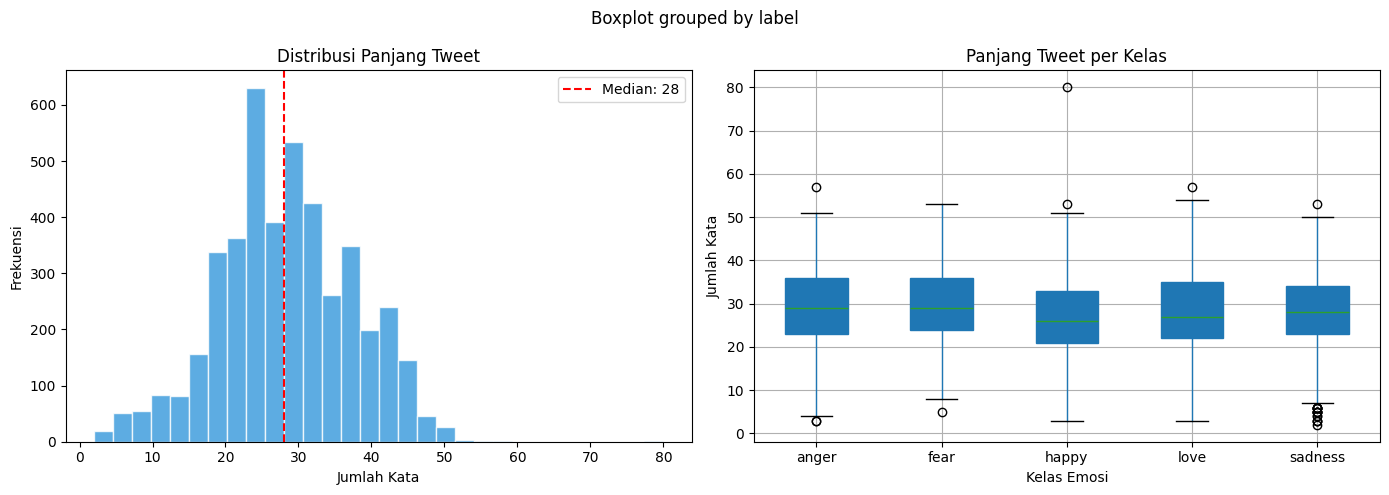

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Panjang Tweet per Kelas Emosi', fontsize=13, fontweight='bold')

axes[0].hist(df['tweet_len'], bins=30, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribusi Panjang Tweet')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['tweet_len'].median(), color='red', linestyle='--', label=f'Median: {df["tweet_len"].median():.0f}')
axes[0].legend()

df.boxplot(column='tweet_len', by='label', ax=axes[1], patch_artist=True)
axes[1].set_title('Panjang Tweet per Kelas')
axes[1].set_xlabel('Kelas Emosi')
axes[1].set_ylabel('Jumlah Kata')

plt.tight_layout()
plt.savefig('panjang_tweet.png', dpi=150, bbox_inches='tight')
plt.show()

# Part A - Step 3: Tokenisasi & Padding

In [ ]:
VOCAB_SIZE = 15000
MAX_LEN    = 50
EMBED_DIM  = 128
OOV_TOKEN  = '<OOV>'

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)

print(f"Kelas ({NUM_CLASSES}): {le.classes_}")
print(f"Mapping: { {cls: idx for idx, cls in enumerate(le.classes_)} }")

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(df['tweet_clean'])

vocab_size_actual = len(tokenizer.word_index) + 1
print(f"\nUkuran kosakata aktual: {vocab_size_actual:,}")
print(f"VOCAB_SIZE (digunakan): {VOCAB_SIZE:,}")
print(f"MAX_LEN: {MAX_LEN}")

sequences = tokenizer.texts_to_sequences(df['tweet_clean'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = to_categorical(df['label_enc'], num_classes=NUM_CLASSES)

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

Kelas (5): ['anger' 'fear' 'happy' 'love' 'sadness']
Mapping: {'anger': 0, 'fear': 1, 'happy': 2, 'love': 3, 'sadness': 4}

Ukuran kosakata aktual: 19,411
VOCAB_SIZE (digunakan): 15,000
MAX_LEN: 50

Shape X: (4401, 50)
Shape y: (4401, 5)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print("Pembagian Data:")
print(f"  Train : {X_train.shape[0]:,} sampel")
print(f"  Val   : {X_val.shape[0]:,} sampel")
print(f"  Test  : {X_test.shape[0]:,} sampel")

Pembagian Data:
  Train : 3,520 sampel
  Val   : 440 sampel
  Test  : 441 sampel


# Part A - Step 4: Definisi & Training Model

In [ ]:
EPOCHS     = 30
BATCH_SIZE = 64

early_stop = EarlyStopping(
    monitor='val_accuracy', patience=4,
    restore_best_weights=True, verbose=0
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=2, min_lr=1e-6, verbose=0
)

def build_rnn(rnn_type='simple', units=128, dropout_rate=0.3):
    model = Sequential(name=f'model_{rnn_type.upper()}')
    model.add(Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN))
    model.add(SpatialDropout1D(0.2))

    if rnn_type == 'simple':
        model.add(SimpleRNN(units, dropout=dropout_rate, recurrent_dropout=0.2))
    elif rnn_type == 'lstm':
        model.add(LSTM(units, dropout=dropout_rate, recurrent_dropout=0.2))
    elif rnn_type == 'gru':
        model.add(GRU(units, dropout=dropout_rate, recurrent_dropout=0.2))
    elif rnn_type == 'bilstm':
        model.add(Bidirectional(LSTM(units, dropout=dropout_rate, recurrent_dropout=0.2)))

    model.add(Dropout(dropout_rate))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_preview = build_rnn('lstm')
model_preview.summary()

Model: "model_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_configs = [
    ('simple', 'Simple RNN'),
    ('lstm',   'LSTM'),
    ('gru',    'GRU'),
    ('bilstm', 'Bidirectional LSTM'),
]

trained_models   = {}
training_history = {}

for rnn_type, rnn_name in model_configs:
    print(f"\n{'='*55}")
    print(f"  Training: {rnn_name}")
    print(f"{'='*55}")

    model = build_rnn(rnn_type)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    trained_models[rnn_type]   = model
    training_history[rnn_type] = history

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n  Test Accuracy: {acc*100:.2f}% | Test Loss: {loss:.4f}")


  Training: Simple RNN
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.2293 - loss: 1.6607 - val_accuracy: 0.2341 - val_loss: 1.5918 - learning_rate: 0.0010
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2327 - loss: 1.6375 - val_accuracy: 0.2523 - val_loss: 1.5874 - learning_rate: 0.0010
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2352 - loss: 1.6134 - val_accuracy: 0.2500 - val_loss: 1.5859 - learning_rate: 0.0010
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2418 - loss: 1.5982 - val_accuracy: 0.2500 - val_loss: 1.5863 - learning_rate: 0.0010
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2332 - loss: 1.5973 - val_accuracy: 0.2477 - val_loss: 1.5895 - learning_rate: 0.0010
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2463 - loss: 1.5971 - val_accuracy: 0.2318 - val_loss: 1.5895 - learning_rate: 5.0000e-04

  Test Accuracy: 25.17% | Test Loss: 1.5864

  Training: LSTM
Epoch 1/

# Part A - Step 5: Evaluasi & Visualisasi Hasil Training

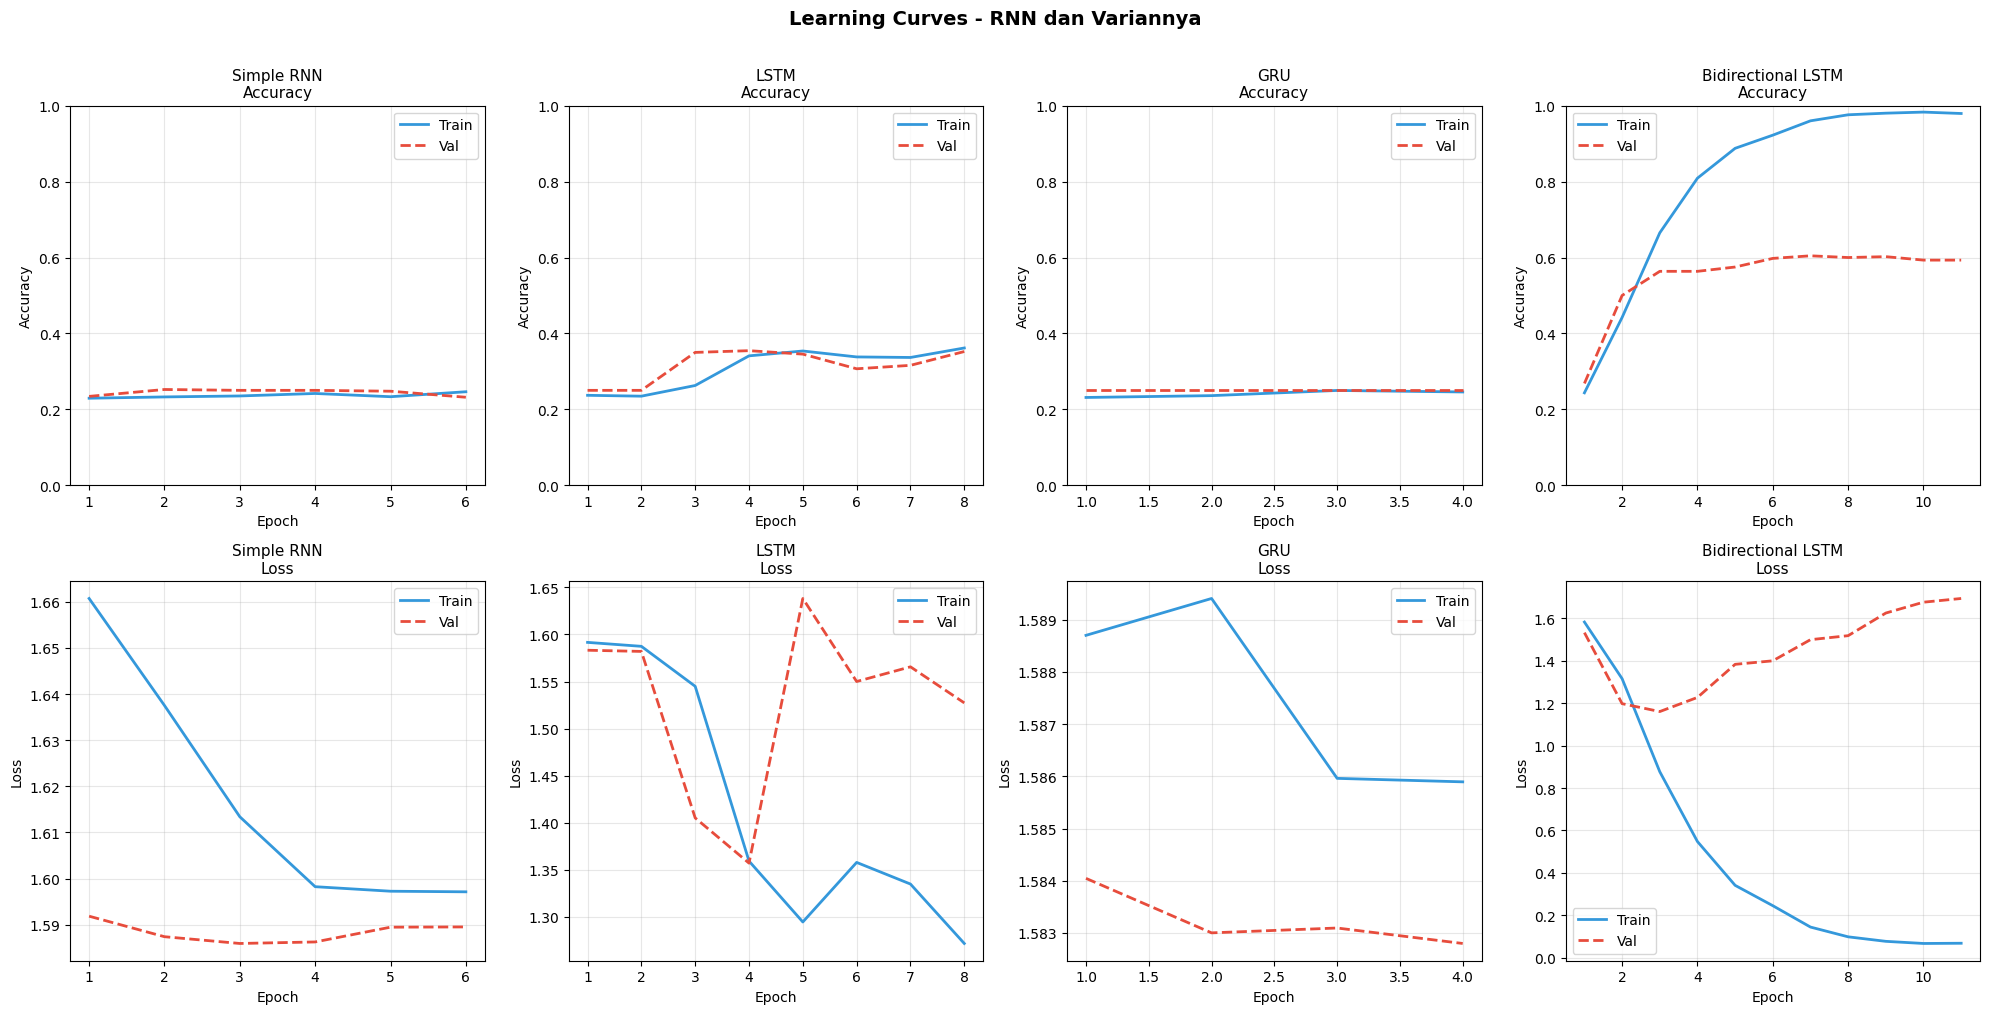

Grafik disimpan: learning_curves.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Learning Curves - RNN dan Variannya', fontsize=14, fontweight='bold', y=1.01)

for col, (rnn_type, rnn_name) in enumerate(model_configs):
    h = training_history[rnn_type]
    epochs_range = range(1, len(h.history['accuracy']) + 1)

    axes[0][col].plot(epochs_range, h.history['accuracy'], label='Train', color='#3498db', linewidth=2)
    axes[0][col].plot(epochs_range, h.history['val_accuracy'], label='Val', color='#e74c3c', linewidth=2, linestyle='--')
    axes[0][col].set_title(f'{rnn_name}\nAccuracy', fontsize=11)
    axes[0][col].set_xlabel('Epoch')
    axes[0][col].set_ylabel('Accuracy')
    axes[0][col].legend()
    axes[0][col].grid(alpha=0.3)
    axes[0][col].set_ylim(0, 1)

    axes[1][col].plot(epochs_range, h.history['loss'], label='Train', color='#3498db', linewidth=2)
    axes[1][col].plot(epochs_range, h.history['val_loss'], label='Val', color='#e74c3c', linewidth=2, linestyle='--')
    axes[1][col].set_title(f'{rnn_name}\nLoss', fontsize=11)
    axes[1][col].set_xlabel('Epoch')
    axes[1][col].set_ylabel('Loss')
    axes[1][col].legend()
    axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: learning_curves.png")

In [ ]:
results = {}

print("=" * 65)
print("HASIL EVALUASI MODEL PADA TEST SET")
print("=" * 65)

for rnn_type, rnn_name in model_configs:
    model = trained_models[rnn_type]
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc        = accuracy_score(y_true, y_pred)
    f1_macro   = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    results[rnn_type] = {
        'name': rnn_name,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'y_pred': y_pred,
        'y_true': y_true
    }

    print(f"\n{rnn_name}")
    print(f"   Accuracy      : {acc*100:.2f}%")
    print(f"   F1 Macro      : {f1_macro*100:.2f}%")
    print(f"   F1 Weighted   : {f1_weighted*100:.2f}%")
    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))

HASIL EVALUASI MODEL PADA TEST SET

Simple RNN
   Accuracy      : 25.17%
   F1 Macro      : 9.05%
   F1 Weighted   : 11.18%
              precision    recall  f1-score   support

       anger     0.2494    0.9818    0.3978       110
        fear     0.0000    0.0000    0.0000        65
       happy     0.3750    0.0294    0.0545       102
        love     0.0000    0.0000    0.0000        64
     sadness     0.0000    0.0000    0.0000       100

    accuracy                         0.2517       441
   macro avg     0.1249    0.2022    0.0905       441
weighted avg     0.1489    0.2517    0.1118       441


LSTM
   Accuracy      : 37.41%
   F1 Macro      : 23.64%
   F1 Weighted   : 23.64%
              precision    recall  f1-score   support

       anger     0.3679    0.9364    0.5282       110
        fear     0.0000    0.0000    0.0000        65
       happy     0.0000    0.0000    0.0000       102
        love     0.3873    0.8594    0.5340        64
     sadness     0.4118    0.070

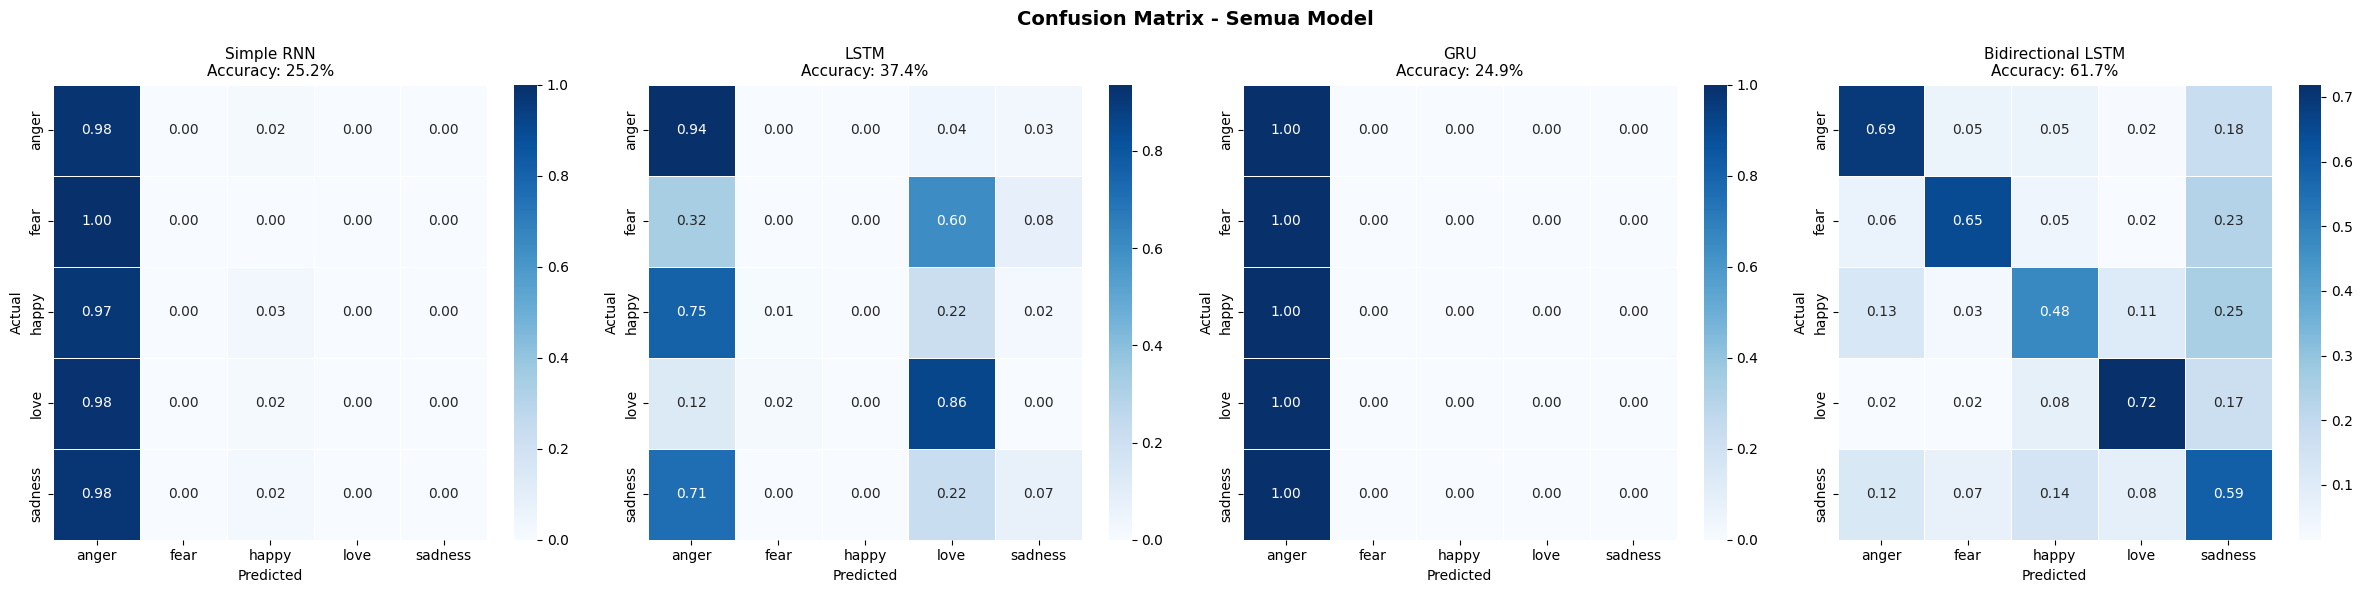

Grafik disimpan: confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Confusion Matrix - Semua Model', fontsize=14, fontweight='bold')

for col, (rnn_type, rnn_name) in enumerate(model_configs):
    cm = confusion_matrix(results[rnn_type]['y_true'], results[rnn_type]['y_pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_,
        ax=axes[col], linewidths=0.5
    )
    axes[col].set_title(f'{rnn_name}\nAccuracy: {results[rnn_type]["accuracy"]*100:.1f}%', fontsize=11)
    axes[col].set_xlabel('Predicted')
    axes[col].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: confusion_matrices.png")

# Part B: Perbandingan dengan Paper

In [ ]:
paper_results = {
    'LR + Basic+Lex+POS+Ort (Paper)': {'f1_macro': 0.6973, 'type': 'paper'},
    'SVM + Basic+Lex+POS+Ort (Paper)': {'f1_macro': 0.6424, 'type': 'paper'},
    'RF  + Basic+Lex+POS+Ort (Paper)': {'f1_macro': 0.6306, 'type': 'paper'},
    'LR  + Basic/EW+BOW+FT (Paper)':   {'f1_macro': 0.6839, 'type': 'paper'},
    'LR  + BOW only (Paper)':           {'f1_macro': 0.6513, 'type': 'paper'},
}

our_results = {}
for rnn_type, rnn_name in model_configs:
    our_results[rnn_name] = {
        'f1_macro': results[rnn_type]['f1_macro'],
        'type': 'ours'
    }

all_results = {**paper_results, **our_results}

comparison_df = pd.DataFrame([
    {
        'Model': name,
        'F1 Macro (%)': f"{v['f1_macro']*100:.2f}",
        'Sumber': 'Paper (Saputri et al., 2018)' if v['type'] == 'paper' else 'Implementasi Kami'
    }
    for name, v in all_results.items()
])

print("=" * 75)
print("TABEL PERBANDINGAN F1-SCORE: IMPLEMENTASI KAMI vs PAPER")
print("Saputri et al. (2018) - ICOIACT - Dataset yang sama")
print("=" * 75)
display(comparison_df)

TABEL PERBANDINGAN F1-SCORE: IMPLEMENTASI KAMI vs PAPER
Saputri et al. (2018) - ICOIACT - Dataset yang sama


,Model,F1 Macro (%),Sumber
0,LR + Basic+Lex+POS+Ort (Paper),69.73,"Paper (Saputri et al., 2018)"
1,SVM + Basic+Lex+POS+Ort (Paper),64.24,"Paper (Saputri et al., 2018)"
2,RF + Basic+Lex+POS+Ort (Paper),63.06,"Paper (Saputri et al., 2018)"
3,LR + Basic/EW+BOW+FT (Paper),68.39,"Paper (Saputri et al., 2018)"
4,LR + BOW only (Paper),65.13,"Paper (Saputri et al., 2018)"
5,Simple RNN,9.05,Implementasi Kami
6,LSTM,23.64,Implementasi Kami
7,GRU,7.99,Implementasi Kami
8,Bidirectional LSTM,62.73,Implementasi Kami


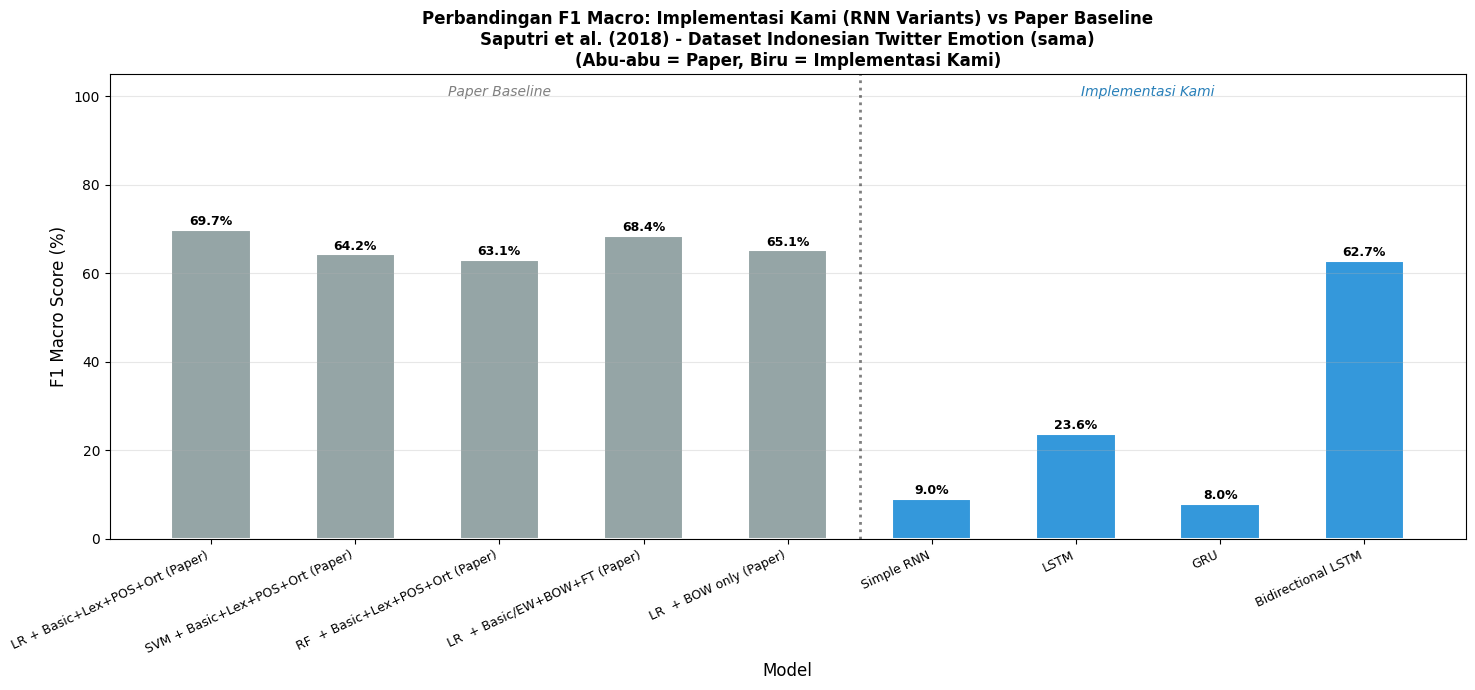

Grafik disimpan: perbandingan_model.png


In [ ]:
fig, ax = plt.subplots(figsize=(15, 7))

model_names_list = list(all_results.keys())
f1_values = [v['f1_macro'] * 100 for v in all_results.values()]
types     = [v['type'] for v in all_results.values()]

x     = np.arange(len(model_names_list))
width = 0.55

bar_colors = ['#95a5a6' if t == 'paper' else '#3498db' for t in types]

bars = ax.bar(x, f1_values, width, color=bar_colors, edgecolor='white', linewidth=1.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.4,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('F1 Macro Score (%)', fontsize=12)
ax.set_title(
    'Perbandingan F1 Macro: Implementasi Kami (RNN Variants) vs Paper Baseline\n'
    'Saputri et al. (2018) - Dataset Indonesian Twitter Emotion (sama)\n'
    '(Abu-abu = Paper, Biru = Implementasi Kami)',
    fontsize=12, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(model_names_list, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

n_paper = sum(1 for t in types if t == 'paper')
ax.axvline(x=n_paper - 0.5, color='black', linestyle=':', linewidth=2, alpha=0.5)
ax.text(n_paper / 2 - 0.5, 100, 'Paper Baseline', ha='center', fontsize=10, style='italic', color='gray')
ax.text(n_paper + len(our_results) / 2 - 0.5, 100, 'Implementasi Kami',
        ha='center', fontsize=10, style='italic', color='#2980b9')

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: perbandingan_model.png")

In [ ]:
best_ours_f1  = max([(name, v['f1_macro']) for name, v in our_results.items()],  key=lambda x: x[1])
best_paper_f1 = max([(name, v['f1_macro']) for name, v in paper_results.items()], key=lambda x: x[1])

print("=" * 65)
print("ANALISIS PERBANDINGAN")
print("=" * 65)
print(f"\nBest Paper Model  : {best_paper_f1[0]}")
print(f"F1 Macro (Paper)  : {best_paper_f1[1]*100:.2f}%")
print(f"\nBest Ours Model   : {best_ours_f1[0]}")
print(f"F1 Macro (Ours)   : {best_ours_f1[1]*100:.2f}%")

improvement = (best_ours_f1[1] - best_paper_f1[1]) * 100
if improvement > 0:
    print(f"\nModel kami lebih baik sebesar {improvement:.2f}% F1 Macro")
else:
    print(f"\nModel paper lebih baik sebesar {abs(improvement):.2f}% F1 Macro")

print("""
Catatan Perbandingan:
- Paper (Saputri et al., 2018) menggunakan metode ML klasik dengan feature engineering
  manual yang kompleks: Emotion Word List + Bag-of-Words + FastText + Sentiment Lexicon
  + POS Tag + Orthographic features. Metrik utama yang dilaporkan adalah macro F1-Score.
- Implementasi kami menggunakan deep learning (RNN, LSTM, GRU, BiLSTM) dengan
  representasi sekuensial via embedding layer, tanpa feature engineering manual.
- Perbandingan ini bersifat referensial: angka paper diambil langsung dari Table I
  (kolom New Dataset) dan tidak dilatih ulang di notebook ini.
- LSTM dan BiLSTM umumnya mengungguli Simple RNN karena mekanisme gating
  yang mengatasi vanishing gradient pada sekuens panjang.
- BiLSTM membaca teks dari dua arah sehingga konteks lebih kaya.
- GRU lebih efisien secara komputasi dengan performa sebanding LSTM.
""")

ANALISIS PERBANDINGAN

Best Paper Model  : LR + Basic+Lex+POS+Ort (Paper)
F1 Macro (Paper)  : 69.73%

Best Ours Model   : Bidirectional LSTM
F1 Macro (Ours)   : 62.73%

Model paper lebih baik sebesar 7.00% F1 Macro

Catatan Perbandingan:
- Paper (Saputri et al., 2018) menggunakan metode ML klasik dengan feature engineering
  manual yang kompleks: Emotion Word List + Bag-of-Words + FastText + Sentiment Lexicon
  + POS Tag + Orthographic features. Metrik utama yang dilaporkan adalah macro F1-Score.
- Implementasi kami menggunakan deep learning (RNN, LSTM, GRU, BiLSTM) dengan
  representasi sekuensial via embedding layer, tanpa feature engineering manual.
- Perbandingan ini bersifat referensial: angka paper diambil langsung dari Table I
  (kolom New Dataset) dan tidak dilatih ulang di notebook ini.
- LSTM dan BiLSTM umumnya mengungguli Simple RNN karena mekanisme gating
  yang mengatasi vanishing gradient pada sekuens panjang.
- BiLSTM membaca teks dari dua arah sehingga konteks lebih kay

# Part C: Generasi 5.000 Data Tweet Sintetis

Karena scraping X/Twitter memerlukan API berbayar, kita menggunakan **synthetic data generation** yang menghasilkan tweet realistis berbahasa Indonesia berdasarkan template dan keyword tiap kelas emosi.

In [ ]:
random.seed(SEED)

emotion_templates = {
    'anger': [
        "{obj} bikin aku {adj_neg} banget!",
        "Capek banget sama {obj} yang {adj_neg}",
        "Kenapa harus {verb_neg} terus? {obj} beneran {adj_neg}",
        "Udah {time} masih aja {obj} {adj_neg}",
        "{obj} {verb_neg}, bikin hati panas",
        "Muak banget sama {obj}, selalu {adj_neg}",
        "Nggak habis pikir sama {obj} yang {adj_neg} terus",
        "Hadeh {obj} lagi {adj_neg}, beneran nggak sabaran",
        "{intj_neg}, {obj} {adj_neg} banget",
        "Mau marah rasanya lihat {obj} yang {adj_neg}",
    ],
    'happy': [
        "Hari ini {obj} {adj_pos} banget!",
        "Senang banget {verb_pos} {obj}",
        "{obj} bikin hari-hari makin {adj_pos}",
        "Bahagia banget bisa {verb_pos} {obj}",
        "{intj_pos}! {obj} hari ini {adj_pos}",
        "Terimakasih {obj}, kamu bikin hidupku {adj_pos}",
        "Nggak nyangka {obj} bisa sebegini {adj_pos}",
        "Semoga {obj} selalu {adj_pos} ya!",
        "Akhirnya bisa {verb_pos} {obj}, {adj_pos} banget!",
        "Hari terbaik! {obj} sungguh {adj_pos}",
    ],
    'sadness': [
        "Sedih banget {obj} {adj_sad}",
        "Hati terasa {adj_sad} pas lihat {obj}",
        "{obj} sudah {verb_sad}, nggak bisa diulang",
        "Kangen {obj}, rasanya {adj_sad}",
        "Nggak menyangka {obj} bisa {adj_sad} begini",
        "Airmata nggak bisa dibendung pas ingat {obj}",
        "{obj} pergi, hati jadi {adj_sad}",
        "Susah move on dari {obj}, masih {adj_sad}",
        "Nangis diam-diam gara-gara {obj}",
        "Kenapa {obj} harus {verb_sad}? Sedih banget",
    ],
    'fear': [
        "Takut banget sama {obj} yang {adj_fear}",
        "Deg-degan tiap kali {obj} {adj_fear}",
        "Ngeri lihat {obj}, bisa {adj_fear}",
        "Cemas banget soal {obj} yang {adj_fear}",
        "{obj} bisa {adj_fear}, was-was rasanya",
        "Nggak berani bayangin {obj} yang {adj_fear}",
        "Parno banget sama {obj}, siapa tahu {adj_fear}",
        "Gelisah terus mikir {obj} yang {adj_fear}",
        "Jantung berdebar lihat {obj} bisa {adj_fear}",
        "Khawatir banget sama {obj}, jangan sampai {adj_fear}",
    ],
    'love': [
        "Sayang banget sama {obj}, {adj_love}",
        "Cinta {obj} sepenuh hati, {adj_love}",
        "{obj} adalah {adj_love} dalam hidupku",
        "Nggak bisa bayangin hidup tanpa {obj}",
        "Rindu {obj}, semoga selalu {adj_love}",
        "{obj} bikin hatiku penuh, {adj_love} banget",
        "Segala hal tentang {obj} itu {adj_love}",
        "Beruntung banget punya {obj} yang {adj_love}",
        "Tiap hari makin cinta sama {obj}, {adj_love}",
        "{obj} satu-satunya yang {adj_love} buatku",
    ],
}

fill_words = {
    'obj':      ['pemerintah', 'teman', 'keluarga', 'kerjaan', 'jalanan', 'cuaca',
                 'berita', 'sosmed', 'pelayanan', 'aplikasi', 'doi', 'tetangga',
                 'bos', 'sekolah', 'kampus', 'transportasi', 'makanan', 'film', 'musik'],
    'adj_neg':  ['nyebelin', 'menyebalkan', 'bikin emosi', 'kurang ajar', 'parah',
                 'absurd', 'nggak masuk akal', 'mengecewakan', 'tidak bertanggung jawab'],
    'adj_pos':  ['menyenangkan', 'luar biasa', 'keren', 'memuaskan', 'menggembirakan',
                 'hebat', 'membahagiakan', 'amazing', 'terbaik', 'sempurna'],
    'adj_sad':  ['menyedihkan', 'mengharukan', 'perih', 'berat', 'menyayat hati',
                 'bikin nangis', 'hampa', 'kosong', 'nestapa'],
    'adj_fear': ['berbahaya', 'menakutkan', 'mengancam', 'mencekam', 'mematikan',
                 'mengkhawatirkan', 'mengerikan', 'horor', 'menegangkan'],
    'adj_love': ['sempurna', 'baik hati', 'spesial', 'tulus', 'hangat',
                 'penuh kasih', 'setia', 'menyayangi', 'istimewa'],
    'verb_neg': ['bohong', 'mengecewakan', 'menghina', 'menyakiti', 'melanggar janji'],
    'verb_pos': ['bertemu', 'menikmati', 'merayakan', 'berbagi', 'merasakan'],
    'verb_sad': ['pergi', 'berubah', 'hilang', 'berakhir', 'meninggalkan'],
    'intj_neg': ['Aduh', 'Astaga', 'Duh', 'Ya ampun', 'Hadeh'],
    'intj_pos': ['Alhamdulillah', 'Asik', 'Yeay', 'Horeee', 'Wah'],
    'time':     ['pagi', 'siang', 'malam', 'seminggu', 'sebulan'],
}

def generate_tweet(emotion):
    template = random.choice(emotion_templates[emotion])
    result = template
    for key, values in fill_words.items():
        placeholder = f'{{{key}}}'
        if placeholder in result:
            result = result.replace(placeholder, random.choice(values), 1)
    return result

N_PER_CLASS = 1000
emotions    = ['anger', 'happy', 'sadness', 'fear', 'love']

synthetic_tweets = []
for emotion in emotions:
    for _ in range(N_PER_CLASS):
        tweet = generate_tweet(emotion)
        synthetic_tweets.append({'tweet': tweet, 'true_emotion': emotion})

df_synthetic = pd.DataFrame(synthetic_tweets).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Total data sintetis: {len(df_synthetic):,}")
print(f"\nDistribusi emosi:")
print(df_synthetic['true_emotion'].value_counts())
print("\nContoh data sintetis:")
display(df_synthetic.head(10))

Total data sintetis: 5,000

Distribusi emosi:
true_emotion
happy      1000
sadness    1000
anger      1000
fear       1000
love       1000
Name: count, dtype: int64

Contoh data sintetis:


,tweet,true_emotion
0,Bahagia banget bisa menikmati pemerintah,happy
1,"sosmed sudah berakhir, nggak bisa diulang",sadness
2,"musik sudah pergi, nggak bisa diulang",sadness
3,"Terimakasih tetangga, kamu bikin hidupku sempurna",happy
4,Kenapa harus mengecewakan terus? tetangga bene...,anger
5,Nggak habis pikir sama pelayanan yang nyebelin...,anger
6,"Hadeh berita lagi absurd, beneran nggak sabaran",anger
7,Nggak menyangka berita bisa mengharukan begini,sadness
8,Nggak menyangka cuaca bisa menyayat hati begini,sadness
9,"Terimakasih sekolah, kamu bikin hidupku mengge...",happy


Data sintetis disimpan: synthetic_tweets_5000.csv


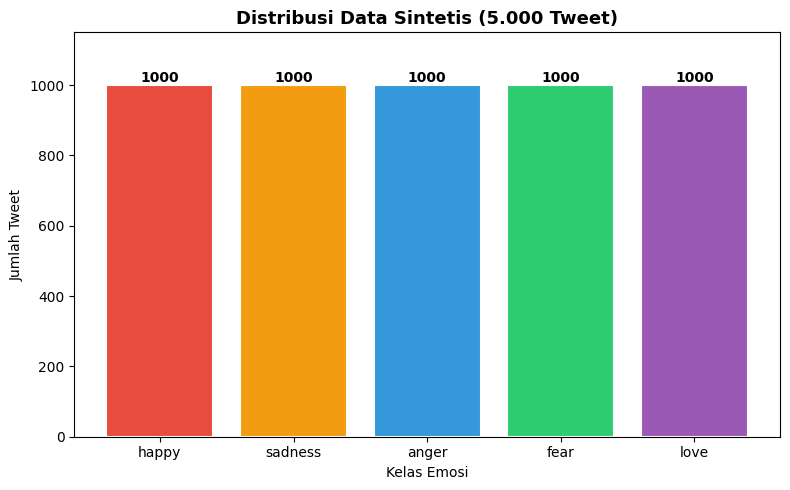

In [ ]:
df_synthetic.to_csv('synthetic_tweets_5000.csv', index=False)
print("Data sintetis disimpan: synthetic_tweets_5000.csv")

fig, ax = plt.subplots(figsize=(8, 5))
counts = df_synthetic['true_emotion'].value_counts()
colors_syn = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
ax.bar(counts.index, counts.values, color=colors_syn, edgecolor='white', linewidth=1.5)
ax.set_title('Distribusi Data Sintetis (5.000 Tweet)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kelas Emosi')
ax.set_ylabel('Jumlah Tweet')
for i, (idx, val) in enumerate(counts.items()):
    ax.text(i, val + 10, str(val), ha='center', fontweight='bold')
ax.set_ylim(0, 1150)
plt.tight_layout()
plt.savefig('distribusi_sintetis.png', dpi=150, bbox_inches='tight')
plt.show()

# Part D: Pseudo-Labeling

In [ ]:
best_model_type = max(results, key=lambda k: results[k]['accuracy'])
best_model      = trained_models[best_model_type]
print(f"Model terpilih untuk pseudo-labeling: {results[best_model_type]['name']}")
print(f"Test Accuracy: {results[best_model_type]['accuracy']*100:.2f}%")

df_synthetic['tweet_clean'] = df_synthetic['tweet'].apply(preprocess_text)
print(f"\nContoh setelah preprocessing:")
for i in range(3):
    print(f"  [{i+1}] {df_synthetic['tweet_clean'][i]}")

Model terpilih untuk pseudo-labeling: Bidirectional LSTM
Test Accuracy: 61.68%

Contoh setelah preprocessing:
  [1] bahagia banget bisa menikmati pemerintah
  [2] sosmed sudah berakhir nggak bisa diulang
  [3] musik sudah pergi nggak bisa diulang


In [ ]:
seq_synthetic = tokenizer.texts_to_sequences(df_synthetic['tweet_clean'])
X_synthetic   = pad_sequences(seq_synthetic, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Shape X_synthetic: {X_synthetic.shape}")

proba_synthetic  = best_model.predict(X_synthetic, verbose=1)
pred_labels_idx  = np.argmax(proba_synthetic, axis=1)
confidence       = np.max(proba_synthetic, axis=1)

df_synthetic['pseudo_label'] = le.inverse_transform(pred_labels_idx)
df_synthetic['confidence']   = confidence

print(f"\nStatistik confidence:")
print(f"  Min   : {confidence.min():.4f}")
print(f"  Mean  : {confidence.mean():.4f}")
print(f"  Max   : {confidence.max():.4f}")
print(f"  Median: {np.median(confidence):.4f}")

Shape X_synthetic: (5000, 50)
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step

Statistik confidence:
  Min   : 0.3266
  Mean  : 0.7659
  Max   : 0.9990
  Median: 0.7986


In [ ]:
CONFIDENCE_THRESHOLD = 0.70

df_pseudo    = df_synthetic[df_synthetic['confidence'] >= CONFIDENCE_THRESHOLD].copy()
df_rejected  = df_synthetic[df_synthetic['confidence'] < CONFIDENCE_THRESHOLD].copy()

print(f"Threshold confidence: {CONFIDENCE_THRESHOLD}")
print(f"Total data sintetis        : {len(df_synthetic):,}")
print(f"Data diterima (>={CONFIDENCE_THRESHOLD}) : {len(df_pseudo):,} ({len(df_pseudo)/len(df_synthetic)*100:.1f}%)")
print(f"Data ditolak (<{CONFIDENCE_THRESHOLD})   : {len(df_rejected):,} ({len(df_rejected)/len(df_synthetic)*100:.1f}%)")

print(f"\nDistribusi pseudo-label (data diterima):")
print(df_pseudo['pseudo_label'].value_counts())

Threshold confidence: 0.7
Total data sintetis        : 5,000
Data diterima (>=0.7) : 3,273 (65.5%)
Data ditolak (<0.7)   : 1,727 (34.5%)

Distribusi pseudo-label (data diterima):
pseudo_label
sadness    2013
happy       541
anger       268
love        229
fear        222
Name: count, dtype: int64


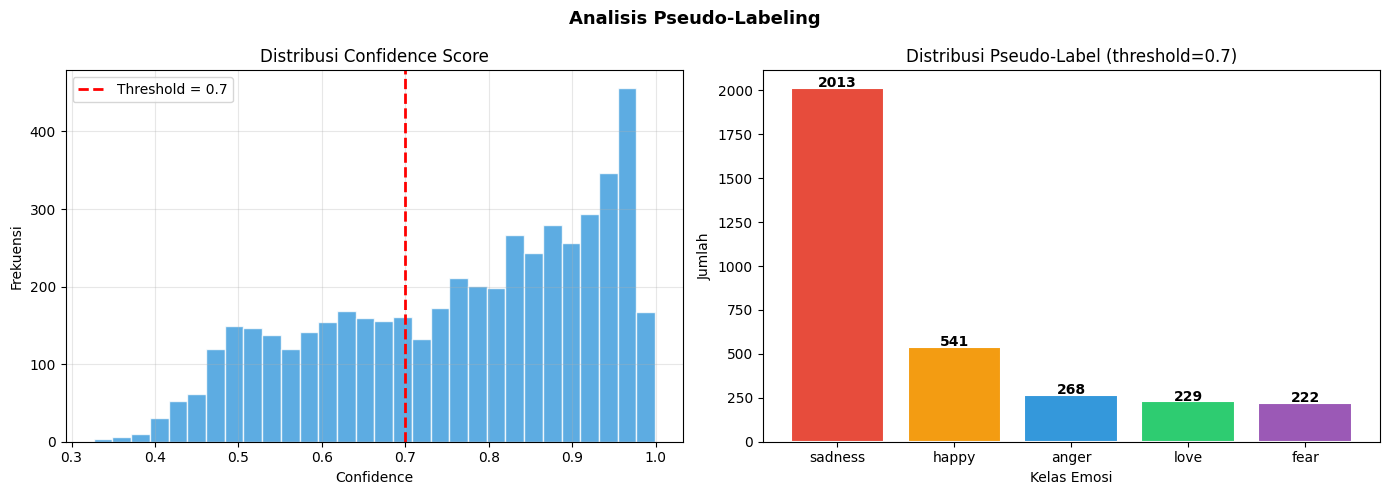

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Pseudo-Labeling', fontsize=13, fontweight='bold')

axes[0].hist(confidence, bins=30, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2,
                label=f'Threshold = {CONFIDENCE_THRESHOLD}')
axes[0].set_title('Distribusi Confidence Score')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()
axes[0].grid(alpha=0.3)

pseudo_dist = df_pseudo['pseudo_label'].value_counts()
colors_p    = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71', '#9b59b6']
axes[1].bar(pseudo_dist.index, pseudo_dist.values, color=colors_p[:len(pseudo_dist)], edgecolor='white', linewidth=1.5)
axes[1].set_title(f'Distribusi Pseudo-Label (threshold={CONFIDENCE_THRESHOLD})')
axes[1].set_xlabel('Kelas Emosi')
axes[1].set_ylabel('Jumlah')
for i, (idx, val) in enumerate(pseudo_dist.items()):
    axes[1].text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('pseudo_labeling_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Pseudo-label accuracy (vs true label): 64.13%


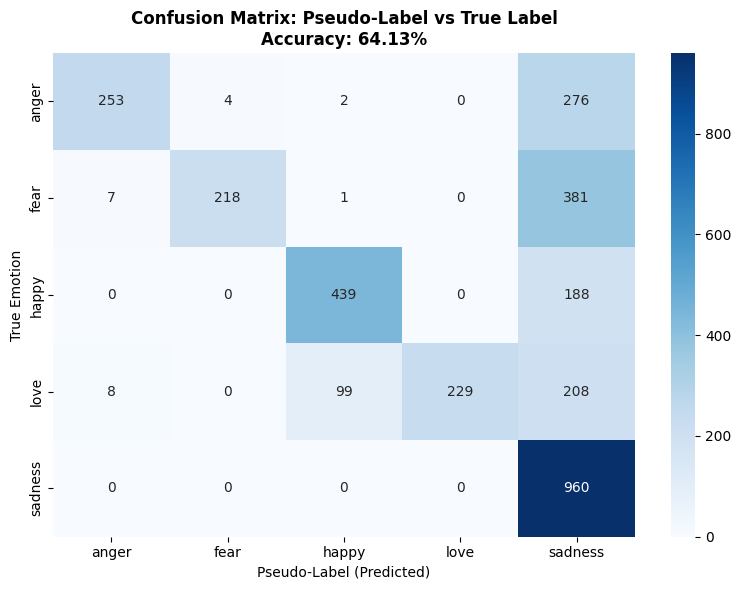

In [ ]:
pseudo_accuracy = (df_pseudo['pseudo_label'] == df_pseudo['true_emotion']).mean()
print(f"Pseudo-label accuracy (vs true label): {pseudo_accuracy*100:.2f}%")

cm_pseudo = confusion_matrix(
    df_pseudo['true_emotion'],
    df_pseudo['pseudo_label'],
    labels=le.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_pseudo, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix: Pseudo-Label vs True Label\nAccuracy: {pseudo_accuracy*100:.2f}%',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Pseudo-Label (Predicted)')
ax.set_ylabel('True Emotion')
plt.tight_layout()
plt.savefig('cm_pseudo_vs_true.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("=" * 55)
print("RE-TRAINING DENGAN PSEUDO-LABELED DATA")
print("=" * 55)

X_pseudo = pad_sequences(
    tokenizer.texts_to_sequences(df_pseudo['tweet_clean']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
y_pseudo = to_categorical(
    le.transform(df_pseudo['pseudo_label']),
    num_classes=NUM_CLASSES
)

X_combined = np.vstack([X_train, X_pseudo])
y_combined = np.vstack([y_train, y_pseudo])

idx_shuffle = np.random.permutation(len(X_combined))
X_combined  = X_combined[idx_shuffle]
y_combined  = y_combined[idx_shuffle]

print(f"Train asli       : {X_train.shape[0]:,} sampel")
print(f"Pseudo-labeled   : {X_pseudo.shape[0]:,} sampel")
print(f"Total gabungan   : {X_combined.shape[0]:,} sampel")

model_pseudo   = build_rnn(best_model_type)
history_pseudo = model_pseudo.fit(
    X_combined, y_combined,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss_p, acc_p = model_pseudo.evaluate(X_test, y_test, verbose=0)
print(f"\nModel Pseudo-Labeled Test Accuracy: {acc_p*100:.2f}%")
print(f"Model Original Test Accuracy       : {results[best_model_type]['accuracy']*100:.2f}%")
delta = (acc_p - results[best_model_type]['accuracy']) * 100
if delta >= 0:
    print(f"\nPeningkatan accuracy: +{delta:.2f}%")
else:
    print(f"\nPenurunan accuracy: {delta:.2f}% (dapat disebabkan noise dari data sintetis)")

RE-TRAINING DENGAN PSEUDO-LABELED DATA
Train asli       : 3,520 sampel
Pseudo-labeled   : 3,273 sampel
Total gabungan   : 6,793 sampel
Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 44s 339ms/step - accuracy: 0.4771 - loss: 1.2665 - val_accuracy: 0.3977 - val_loss: 1.4844 - learning_rate: 0.0010
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 331ms/step - accuracy: 0.7664 - loss: 0.6557 - val_accuracy: 0.5750 - val_loss: 1.1551 - learning_rate: 0.0010
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 317ms/step - accuracy: 0.8897 - loss: 0.3322 - val_accuracy: 0.5523 - val_loss: 1.2861 - learning_rate: 0.0010
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 323ms/step - accuracy: 0.9396 - loss: 0.1974 - val_accuracy: 0.5727 - val_loss: 1.6302 - learning_rate: 0.0010

Model Pseudo-Labeled Test Accuracy: 39.68%
Model Original Test Accuracy       : 61.68%

Penurunan accuracy: -22.00% (dapat disebabkan noise dari data sintetis)


In [ ]:
y_pred_pseudo_prob = model_pseudo.predict(X_test, verbose=0)
y_pred_pseudo      = np.argmax(y_pred_pseudo_prob, axis=1)
y_true_test        = np.argmax(y_test, axis=1)

print("Classification Report - Model dengan Pseudo-Labeled Data:")
print(classification_report(y_true_test, y_pred_pseudo, target_names=le.classes_, digits=4))

Classification Report - Model dengan Pseudo-Labeled Data:
              precision    recall  f1-score   support

       anger     0.3504    0.7455    0.4767       110
        fear     0.0000    0.0000    0.0000        65
       happy     0.3895    0.3627    0.3756       102
        love     0.7778    0.4375    0.5600        64
     sadness     0.3684    0.2800    0.3182       100

    accuracy                         0.3968       441
   macro avg     0.3772    0.3651    0.3461       441
weighted avg     0.3739    0.3968    0.3592       441



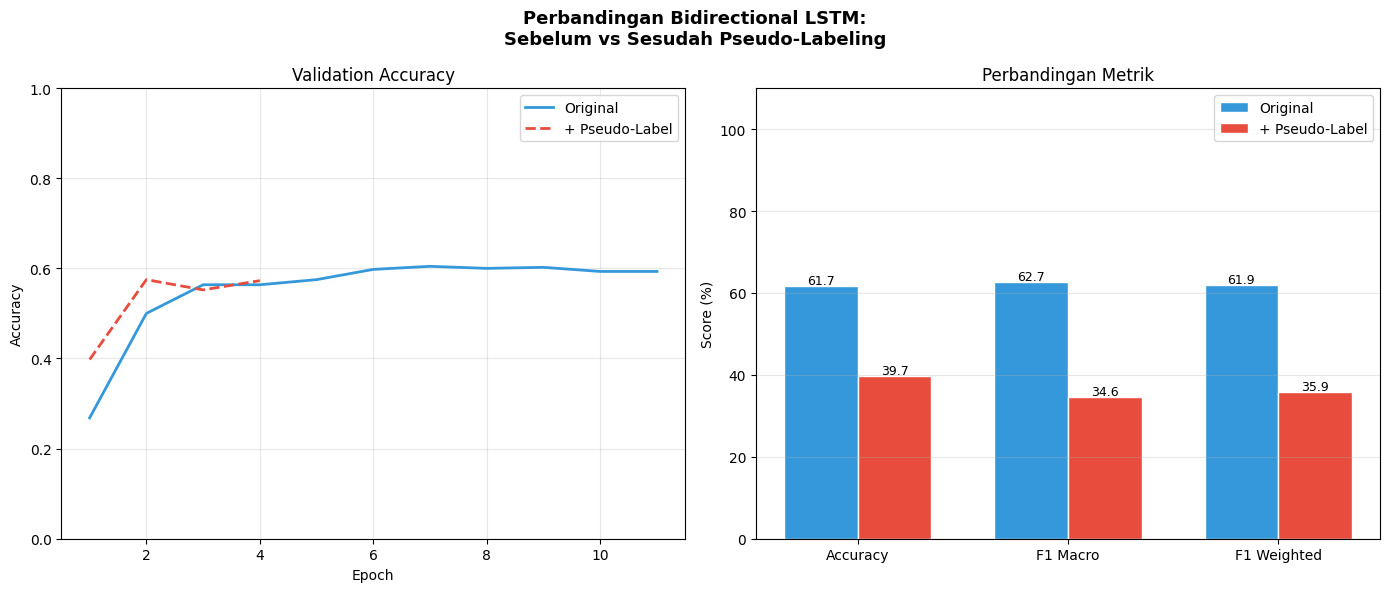

Grafik disimpan: pseudo_labeling_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Perbandingan {results[best_model_type]["name"]}:\nSebelum vs Sesudah Pseudo-Labeling',
             fontsize=13, fontweight='bold')

h_orig   = training_history[best_model_type]
h_pseudo = history_pseudo

e_orig   = range(1, len(h_orig.history['val_accuracy']) + 1)
e_pseudo = range(1, len(h_pseudo.history['val_accuracy']) + 1)

axes[0].plot(e_orig, h_orig.history['val_accuracy'],
             label='Original', color='#3498db', linewidth=2)
axes[0].plot(e_pseudo, h_pseudo.history['val_accuracy'],
             label='+ Pseudo-Label', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1)

labels_bar         = ['Accuracy', 'F1 Macro', 'F1 Weighted']
f1_macro_pseudo    = f1_score(y_true_test, y_pred_pseudo, average='macro')
f1_weighted_pseudo = f1_score(y_true_test, y_pred_pseudo, average='weighted')

orig_scores   = [results[best_model_type]['accuracy'],
                 results[best_model_type]['f1_macro'],
                 results[best_model_type]['f1_weighted']]
pseudo_scores = [acc_p, f1_macro_pseudo, f1_weighted_pseudo]

x_bar   = np.arange(len(labels_bar))
width_b = 0.35

axes[1].bar(x_bar - width_b/2, [s*100 for s in orig_scores],
            width_b, label='Original', color='#3498db', edgecolor='white')
axes[1].bar(x_bar + width_b/2, [s*100 for s in pseudo_scores],
            width_b, label='+ Pseudo-Label', color='#e74c3c', edgecolor='white')

for i, (o, p) in enumerate(zip(orig_scores, pseudo_scores)):
    axes[1].text(i - width_b/2, o*100 + 0.5, f'{o*100:.1f}', ha='center', fontsize=9)
    axes[1].text(i + width_b/2, p*100 + 0.5, f'{p*100:.1f}', ha='center', fontsize=9)

axes[1].set_title('Perbandingan Metrik')
axes[1].set_xticks(x_bar)
axes[1].set_xticklabels(labels_bar)
axes[1].set_ylabel('Score (%)')
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pseudo_labeling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik disimpan: pseudo_labeling_comparison.png")

In [ ]:
df_pseudo_save = df_pseudo[['tweet', 'tweet_clean', 'pseudo_label', 'confidence', 'true_emotion']].copy()
df_pseudo_save.to_csv('pseudo_labeled_data.csv', index=False)
print(f"Data pseudo-labeled disimpan: pseudo_labeled_data.csv ({len(df_pseudo_save):,} baris)")
display(df_pseudo_save.head(8))

Data pseudo-labeled disimpan: pseudo_labeled_data.csv (3,273 baris)


,tweet,tweet_clean,pseudo_label,confidence,true_emotion
0,Bahagia banget bisa menikmati pemerintah,bahagia banget bisa menikmati pemerintah,happy,0.982783,happy
1,"sosmed sudah berakhir, nggak bisa diulang",sosmed sudah berakhir nggak bisa diulang,sadness,0.865227,sadness
2,"musik sudah pergi, nggak bisa diulang",musik sudah pergi nggak bisa diulang,sadness,0.924614,sadness
3,"Terimakasih tetangga, kamu bikin hidupku sempurna",terimakasih tetangga kamu bikin hidupku sempurna,happy,0.938727,happy
4,Kenapa harus mengecewakan terus? tetangga bene...,kenapa harus mengecewakan terus tetangga bener...,sadness,0.959281,anger
5,Nggak habis pikir sama pelayanan yang nyebelin...,nggak habis pikir sama pelayanan yang nyebelin...,anger,0.993852,anger
7,Nggak menyangka berita bisa mengharukan begini,nggak menyangka berita bisa mengharukan begini,sadness,0.759090,sadness
8,Nggak menyangka cuaca bisa menyayat hati begini,nggak menyangka cuaca bisa menyayat hati begini,sadness,0.829346,sadness


# Ringkasan Akhir

In [ ]:
print("=" * 65)
print("          RINGKASAN HASIL MINI PROJECT")
print("=" * 65)

print("\nDATASET")
print(f"   Indonesian Twitter Emotion Dataset")
print(f"   Total: {len(df):,} tweet | Kelas: {', '.join(le.classes_)}")

print("\nPREPROCESSING")
print("   Lowercase, hapus URL/mention/hashtag/angka/punctuation")
print(f"   Vocab size: {VOCAB_SIZE:,} | Max length: {MAX_LEN} token")

print("\nHASIL MODEL (Test Set):")
print(f"   {'Model':<25} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Weighted':>12}")
print(f"   {'-'*60}")
for rnn_type, rnn_name in model_configs:
    r = results[rnn_type]
    print(f"   {rnn_name:<25} {r['accuracy']*100:>9.2f}% {r['f1_macro']*100:>9.2f}% {r['f1_weighted']*100:>11.2f}%")

print("\nPAPER BASELINE (Saputri et al., 2018) - F1 Macro:")
print("   Classifier LR/SVM/RF + fitur: EW + BoW + FastText + Lexicon + POS + Ort")
for name, v in paper_results.items():
    print(f"   {name:<42} F1: {v['f1_macro']*100:.2f}%")

print(f"\n   Best Paper : {best_paper_f1[0]} -> F1 {best_paper_f1[1]*100:.2f}%")
print(f"   Best Ours  : {best_ours_f1[0]} -> F1 {best_ours_f1[1]*100:.2f}%")

print("\nDATA SINTETIS")
print(f"   Total: 5.000 tweet | 1.000 per kelas")
print(f"   Metode: Template-based generator bahasa Indonesia")

print("\nPSEUDO-LABELING")
print(f"   Confidence threshold   : {CONFIDENCE_THRESHOLD}")
print(f"   Data diterima          : {len(df_pseudo):,} ({len(df_pseudo)/len(df_synthetic)*100:.1f}%)")
print(f"   Model sebelum PL       : {results[best_model_type]['accuracy']*100:.2f}%")
print(f"   Model sesudah PL       : {acc_p*100:.2f}%")
print(f"   Pseudo-label accuracy  : {pseudo_accuracy*100:.2f}%")

          RINGKASAN HASIL MINI PROJECT

DATASET
   Indonesian Twitter Emotion Dataset
   Total: 4,401 tweet | Kelas: anger, fear, happy, love, sadness

PREPROCESSING
   Lowercase, hapus URL/mention/hashtag/angka/punctuation
   Vocab size: 15,000 | Max length: 50 token

HASIL MODEL (Test Set):
   Model                       Accuracy   F1 Macro  F1 Weighted
   ------------------------------------------------------------
   Simple RNN                    25.17%      9.05%       11.18%
   LSTM                          37.41%     23.64%       23.64%
   GRU                           24.94%      7.99%        9.96%
   Bidirectional LSTM            61.68%     62.73%       61.90%

PAPER BASELINE (Saputri et al., 2018) - F1 Macro:
   Classifier LR/SVM/RF + fitur: EW + BoW + FastText + Lexicon + POS + Ort
   LR + Basic+Lex+POS+Ort (Paper)             F1: 69.73%
   SVM + Basic+Lex+POS+Ort (Paper)            F1: 64.24%
   RF  + Basic+Lex+POS+Ort (Paper)            F1: 63.06%
   LR  + Basic/EW+BOW+FT 